In [1]:
from pathlib import Path
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import torch
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
def load_experiment(root):

    path = Path(root) / "results.pth"

    if not path.exists():
        print("Missing:", path)
        return None

    data = torch.load(path, weights_only=False)
    rows = data["rows"]

    acc = defaultdict(list)
    nmi = defaultdict(list)
    min_fair = defaultdict(list)
    max_fair = defaultdict(list)
    sep_gap = defaultdict(list)
    soc_gap = defaultdict(list)
    kmeans_costs = defaultdict(list)

    for r in rows:

        lam = r["lambda"]

        acc[lam].append(r["accuracy"])
        nmi[lam].append(r["nmi"])
        min_fair[lam].append(r["min_fair"])
        max_fair[lam].append(r["max_fair"])
        sep_gap[lam].append(r["sep_gap"])
        soc_gap[lam].append(r["soc_gap"])
        kmeans_costs[lam].append(r["kmeans"])

    return {
        "accuracy": acc,
        "nmi": nmi,
        "min_fair_dict": min_fair,
        "max_fair_dict": max_fair,
        "sep_gap": sep_gap,
        "soc_gap": soc_gap,
        "kmeans_costs": kmeans_costs,
    }

def load_all_metrics(
    sep_root="deepfair_results_separation",
    soc_root="deepfair_results_social",
    unifair_root=None,
):

    results = {}

    # separation
    results["separation"] = load_experiment(sep_root)

    # social
    results["social"] = load_experiment(soc_root)

    # unifair modes
    results["unifair"] = {}

    for mode in ["balanced","social_heavy","separation_heavy"]:

        results["unifair"][mode] = load_experiment(
            Path(unifair_root) / mode
        )

    return results

In [3]:
def plot_mnist_usps_metrics(
    sep_metrics,
    soc_metrics,
    lambda_list,
    dataset_name="MNIST-USPS",
    save_root="./plots"
):
    sep_color = "tab:blue"
    soc_color = "tab:orange"
    plt.style.use("seaborn-v0_8-whitegrid")

    x_vals = np.arange(1, len(lambda_list) + 1)

    def lam_label(l):
        return f"{l:.2f}".rstrip("0").rstrip(".")

    tick_labels = [lam_label(l) for l in lambda_list]


    def get_mean_std(d):

        means = []
        stds = []
        for l in lambda_list:
            vals = d[l]
            clean_vals = []
            for v in vals:
                if hasattr(v, "cpu"):
                    v = v.detach().cpu().item()
                clean_vals.append(v)

            means.append(np.mean(clean_vals))
            stds.append(np.std(clean_vals, ddof=1))

        return np.array(means), np.array(stds)

    sep_cost_mean, sep_cost_std = get_mean_std(sep_metrics["kmeans_costs"])
    sep_sep_mean,  sep_sep_std  = get_mean_std(sep_metrics["min_fair_dict"])
    sep_soc_mean,  sep_soc_std  = get_mean_std(sep_metrics["max_fair_dict"])
    soc_cost_mean, soc_cost_std = get_mean_std(soc_metrics["kmeans_costs"])
    soc_sep_mean,  soc_sep_std  = get_mean_std(soc_metrics["min_fair_dict"])
    soc_soc_mean,  soc_soc_std  = get_mean_std(soc_metrics["max_fair_dict"])
    fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
    axes[0].errorbar(
    x_vals, sep_cost_mean, yerr=sep_cost_std,
    fmt="-o", color=sep_color,
    capsize=4, linewidth=2
    )

    axes[0].errorbar(
        x_vals, soc_cost_mean, yerr=soc_cost_std,
        fmt="-s", color=soc_color, capsize=4, linewidth=2
    )

    axes[0].set_ylabel("k-means cost")
    axes[0].set_title(dataset_name)
 
    axes[1].errorbar(
    x_vals, sep_sep_mean, yerr=sep_sep_std,
    fmt="-o", color=sep_color,
    capsize=4, linewidth=2
   )


    axes[1].errorbar(
    x_vals, soc_sep_mean, yerr=soc_sep_std,
    fmt="-s", color=soc_color,
    capsize=4, linewidth=2
  )

    axes[1].set_ylabel("Minimum separation cost")

    axes[2].errorbar(
    x_vals, sep_soc_mean, yerr=sep_soc_std,
    fmt="-o", color=sep_color,
    capsize=4, linewidth=2
    )

    axes[2].errorbar(
        x_vals, soc_soc_mean, yerr=soc_soc_std,
        fmt="-s", color=soc_color,
        capsize=4, linewidth=2
    )

    axes[2].set_ylabel("Maximum social cost")


    # ---------- x axis ----------
    axes[2].set_xticks(x_vals)
    axes[2].set_xticklabels(tick_labels)
    axes[2].set_xlabel(r"$\lambda$")


    for ax in axes:
        ax.grid(alpha=0.4)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    legend_handles = [
        plt.Line2D([], [], color="C0", marker="o", linestyle="-",
                label="Separation fair k-means"),
        plt.Line2D([], [], color="C1", marker="s", linestyle="-",
                label="Social fair k-means"),
     
    ]

    # place legend centered under all axes
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,                 # <-- one row
        fontsize=11,
        frameon=True,
        facecolor="white",
        edgecolor="gray",
        bbox_to_anchor=(0.5, -0.03)   # adjust vertical spacing
    )

    plt.tight_layout()

    save_path = Path(save_root)
    save_path.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        save_path / f"{dataset_name}_fair_clustering_metrics.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [4]:
def plot_unifair_weight_modes(
    results_dict,
    lambda_list,
    dataset_names,
    save_root="./plots",
):

    modes = ["balanced", "social_heavy", "separation_heavy"]

    mode_labels = {
        "balanced": r"Balanced ($\lambda_{sep}=\lambda_{soc}$)",
        "social_heavy": r"Social-heavy ($\lambda_{soc}=3\lambda/4$)",
        "separation_heavy": r"Separation-heavy ($\lambda_{sep}=3\lambda/4$)"
    }

    colors = {
        "balanced": "C4",
        "social_heavy": "C1",
        "separation_heavy": "C0",
    }

    plt.style.use("seaborn-v0_8-whitegrid")

    x_vals = np.arange(1, len(lambda_list) + 1)

    def lam_label(l):
        return f"{l:.2f}".rstrip("0").rstrip(".")

    tick_labels = [lam_label(l) for l in lambda_list]

    # ---------- helper ----------
    def get_mean_std(d):

        means = []
        stds = []

        for l in lambda_list:

            vals = d[l]

            clean_vals = []
            for v in vals:
                if hasattr(v, "cpu"):
                    v = v.detach().cpu().item()
                clean_vals.append(v)

            means.append(np.mean(clean_vals))
            stds.append(np.std(clean_vals, ddof=1))

        return np.array(means), np.array(stds)


    #fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
    fig, axes = plt.subplots(2, 3, figsize=(4*3, 5), sharex=False)
    
    for row, dataset_name in enumerate(dataset_names):

        unifair_results = results_dict[dataset_name]

        for mode in modes:

            metrics = unifair_results[mode]

            cost_mean, cost_std = get_mean_std(metrics["kmeans_costs"])
            sep_mean, sep_std = get_mean_std(metrics["min_fair_dict"])
            soc_mean, soc_std = get_mean_std(metrics["max_fair_dict"])

            axes[row,0].errorbar(
                x_vals, cost_mean, yerr=cost_std,
                fmt="-o", linewidth=2, markersize=6, capsize=4,
                color=colors[mode], label=mode_labels[mode]
            )

            axes[row,1].errorbar(
                x_vals, sep_mean, yerr=sep_std,
                fmt="-o", linewidth=2, markersize=6, capsize=4,
                color=colors[mode]
            )

            axes[row,2].errorbar(
                x_vals, soc_mean, yerr=soc_std,
                fmt="-o", linewidth=2, markersize=6, capsize=4,
                color=colors[mode]
            )


    # labels
    axes[0,0].set_title("k-means cost", fontsize=10)
    axes[0,1].set_title("Separation Fairness", fontsize=10)
    axes[0,2].set_title("Social Cost", fontsize=10)

    axes[1,0].set_ylabel("Color Reverse MNIST", fontsize=10)
    axes[0,0].set_ylabel("MNIST-USPS", fontsize=10)
    
    for ax in axes.flatten():
        ax.set_xticks(x_vals)
        ax.set_xticklabels(tick_labels)
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(alpha=0.4)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    # only second row gets the xlabel
    for ax in axes[1, :]:
        ax.set_xlabel(r"$\lambda$", fontsize=8)
    legend_handles = [
        plt.Line2D([], [], color=colors["balanced"], marker="o", linestyle="-",
                   label=mode_labels["balanced"]),
        plt.Line2D([], [], color=colors["separation_heavy"], marker="o", linestyle="-",
                   label=mode_labels["separation_heavy"]),
        plt.Line2D([], [], color=colors["social_heavy"], marker="o", linestyle="-",
                   label=mode_labels["social_heavy"]),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        fontsize=9,
        frameon=True,
        facecolor="white",
        edgecolor="gray",
        bbox_to_anchor=(0.5, -0.07)
    )

    plt.tight_layout()

    Path(save_root).mkdir(parents=True, exist_ok=True)

    plt.savefig(
        Path(save_root) / f"deep_unifair_weight_modes.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

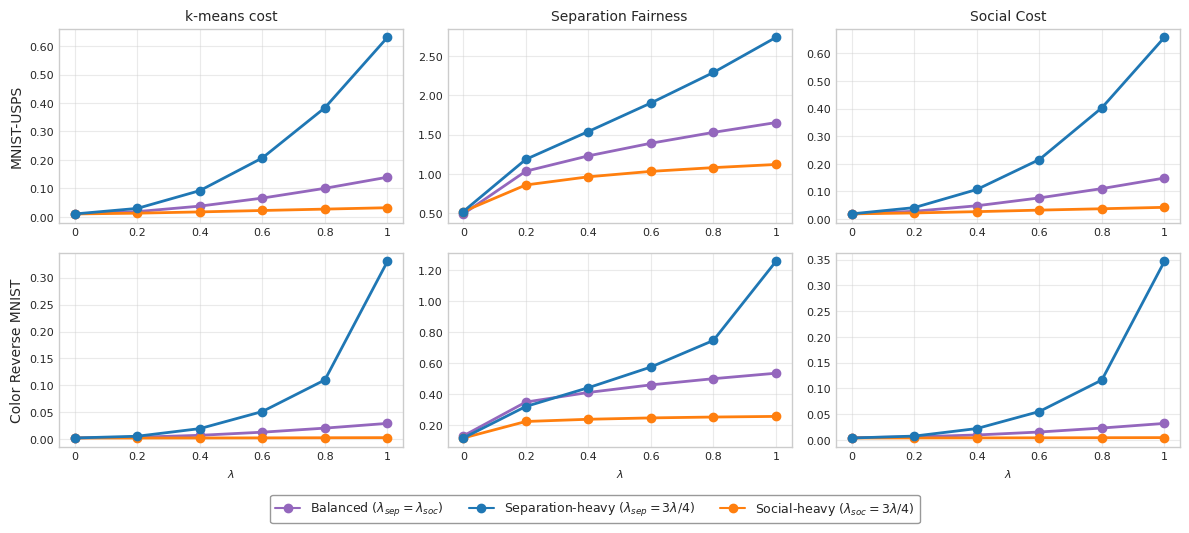

In [5]:
metrics_rev = load_all_metrics(
    unifair_root="deepfair_results_unifair_mnist_reversed"
)

metrics_usps = load_all_metrics(
    unifair_root="deepfair_results_unifair"
)

results_dict = {
    "MNIST-USPS": metrics_usps["unifair"],
    "Color Reversed MNIST": metrics_rev["unifair"]
    
}

plot_unifair_weight_modes(
    results_dict,
    lambda_list=[0.0,0.2,0.4,0.6,0.8,1.0],
    dataset_names=["MNIST-USPS", "Color Reversed MNIST"]
)